In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn plotly imbalanced-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

In [3]:
np.random.seed(42)
n = 5000

data = pd.DataFrame()

data['customer_id'] = ['CUST_' + str(i).zfill(4) for i in range(n)]
data['age'] = np.random.randint(18, 76, n)
data['gender'] = np.random.choice(['Male','Female','Other'], n)
data['tenure_months'] = np.random.randint(1, 73, n)

data['contract_type'] = np.random.choice(['Month-to-month','One year','Two year'], n, p=[0.6,0.25,0.15])
data['payment_method'] = np.random.choice(['Electronic check','Mailed check','Bank transfer','Credit card'], n)
data['monthly_charges'] = np.random.uniform(20,150,n)

data['internet_service'] = np.random.choice(['DSL','Fiber optic','No'], n)
data['online_security'] = np.random.choice(['Yes','No'], n)
data['tech_support'] = np.random.choice(['Yes','No'], n)
data['streaming_services'] = np.random.choice(['Yes','No'], n)
data['phone_service'] = np.random.choice(['Yes','No'], n)

data['num_complaints'] = np.random.randint(0,11,n)
data['customer_service_calls'] = np.random.randint(0,16,n)

data['total_charges'] = data['tenure_months'] * data['monthly_charges'] + np.random.normal(0,100,n)

In [4]:
churn_prob = (
    0.35*(data['contract_type']=='Month-to-month').astype(int) +
    0.25*(data['payment_method']=='Electronic check').astype(int) +
    0.30*(data['num_complaints']/10) +
    0.25*(data['customer_service_calls']/15) +
    0.30*(data['tech_support']=='No').astype(int) -
    0.30*(data['tenure_months']/72)
)

churn_prob = 1/(1+np.exp(-churn_prob))

data['churn'] = np.where(np.random.rand(n) < churn_prob, 'Yes','No')

In [5]:
data['churn'].value_counts(normalize=True)

,proportion
churn,
Yes,0.6284
No,0.3716


In [6]:
data.to_csv("telecom_churn.csv", index=False)

In [7]:
import pandas as pd
data = pd.read_csv("telecom_churn.csv")

Shape


In [8]:
data.shape

(5000, 16)

Data Types

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   object 
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   object 
 3   tenure_months           5000 non-null   int64  
 4   contract_type           5000 non-null   object 
 5   payment_method          5000 non-null   object 
 6   monthly_charges         5000 non-null   float64
 7   internet_service        5000 non-null   object 
 8   online_security         5000 non-null   object 
 9   tech_support            5000 non-null   object 
 10  streaming_services      5000 non-null   object 
 11  phone_service           5000 non-null   object 
 12  num_complaints          5000 non-null   int64  
 13  customer_service_calls  5000 non-null   int64  
 14  total_charges           5000 non-null   

Statistical Summary

In [11]:
data.describe()

,age,tenure_months,monthly_charges,num_complaints,customer_service_calls,total_charges
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,46.672800,36.619800,84.894107,4.966200,7.484200,3120.617611
std,16.630005,20.728038,37.599687,3.127205,4.557006,2396.239559
min,18.000000,1.000000,20.001208,0.000000,0.000000,-138.102092
25%,32.000000,19.000000,52.219207,2.000000,4.000000,1211.857825
50%,47.000000,37.000000,84.268661,5.000000,7.000000,2521.683515
75%,61.000000,55.000000,117.726817,8.000000,11.000000,4498.604234
max,75.000000,72.000000,149.960328,10.000000,15.000000,10845.933696


Target variable analysis

In [12]:
data['churn'].value_counts()
data['churn'].value_counts(normalize=True)

,proportion
churn,
Yes,0.6284
No,0.3716


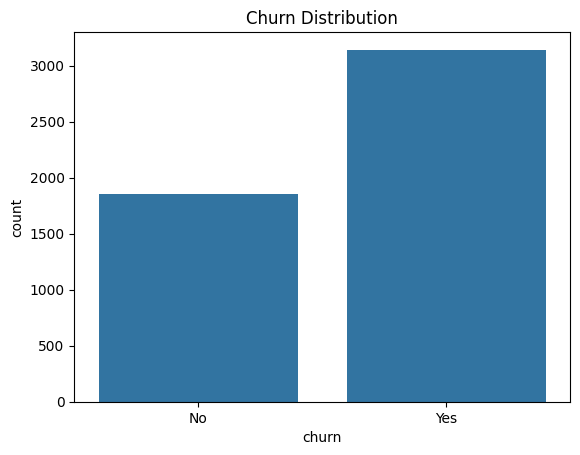

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='churn', data=data)
plt.title("Churn Distribution")
plt.show()

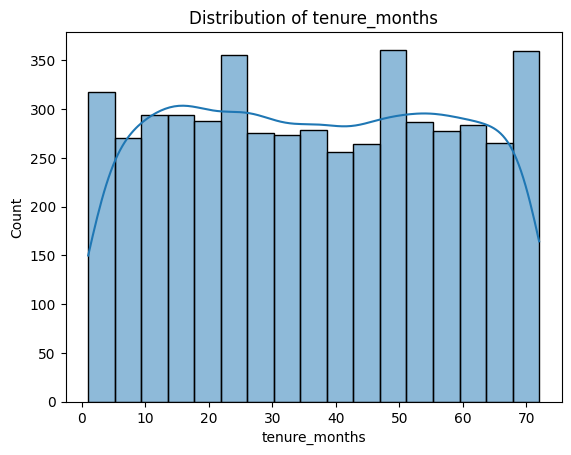

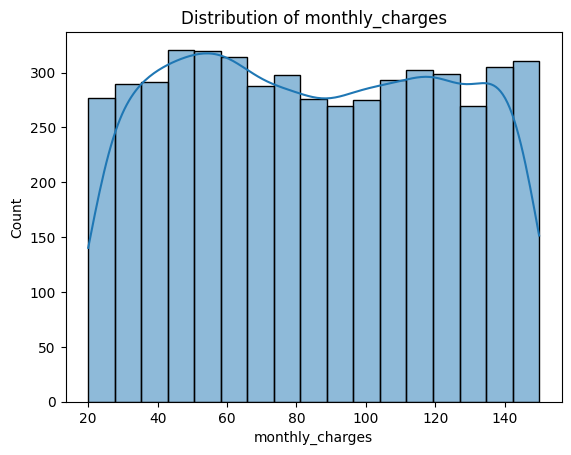

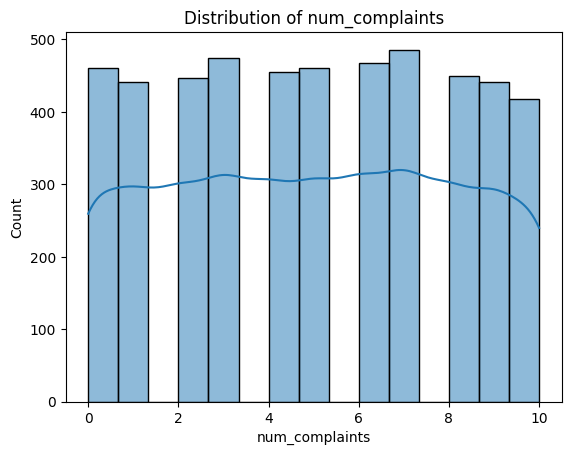

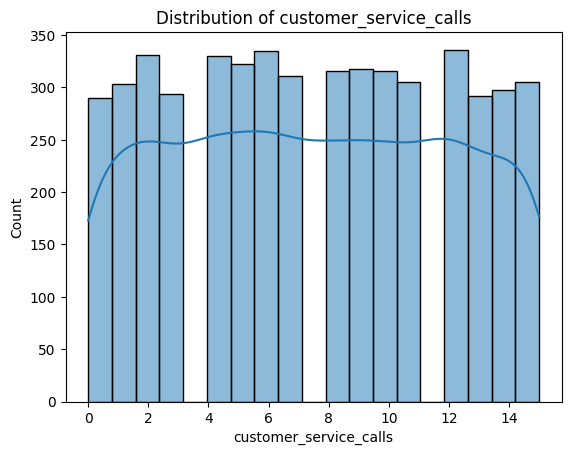

In [14]:
numeric_cols = ['tenure_months','monthly_charges','num_complaints','customer_service_calls']

for col in numeric_cols:
    sns.histplot(data[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

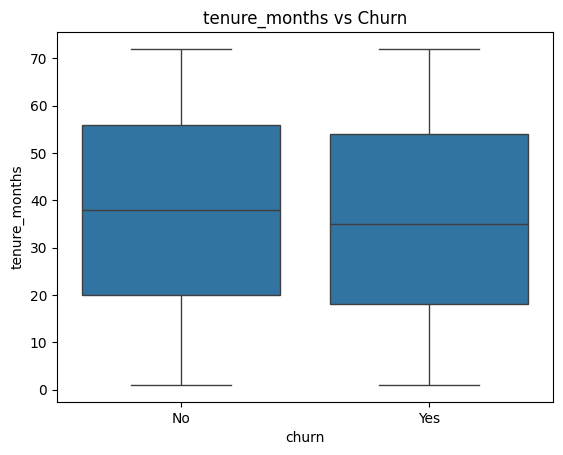

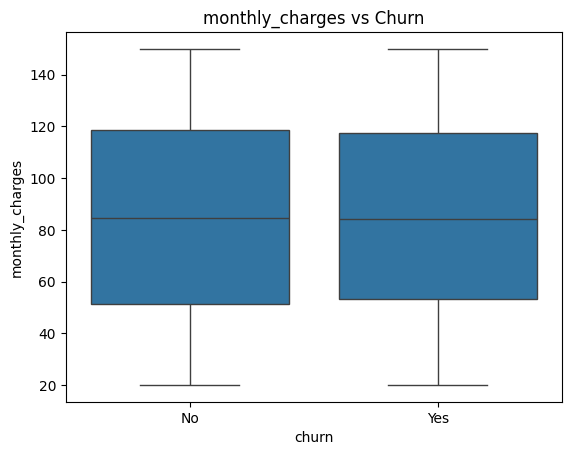

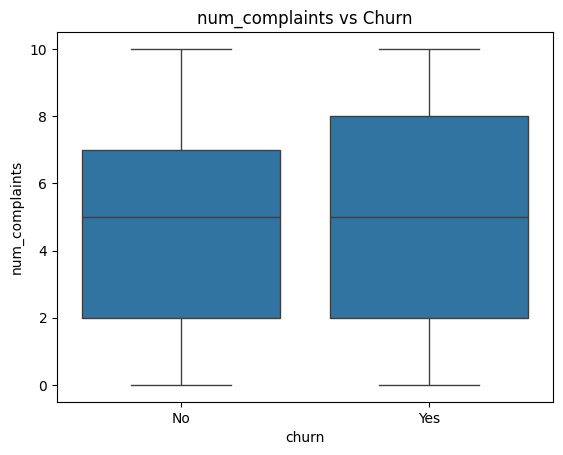

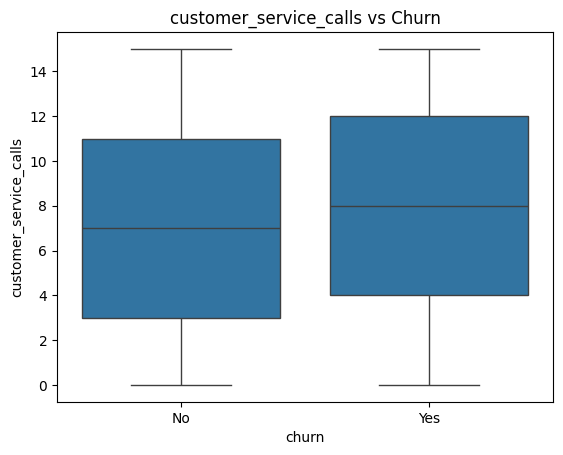

In [15]:
for col in numeric_cols:
    sns.boxplot(x='churn', y=col, data=data)
    plt.title(f"{col} vs Churn")
    plt.show()

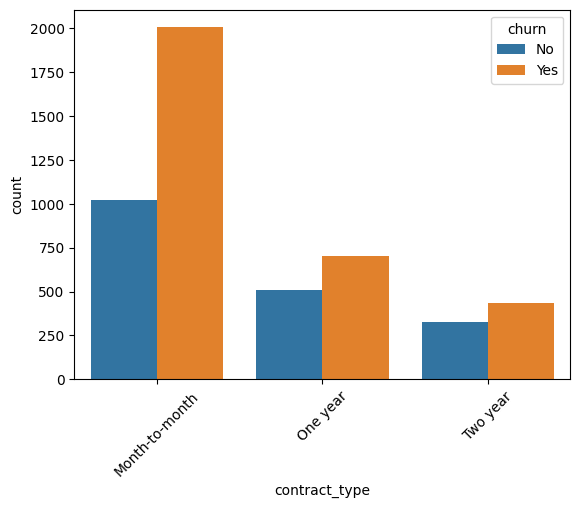

In [16]:
sns.countplot(x='contract_type', hue='churn', data=data)
plt.xticks(rotation=45)
plt.show()

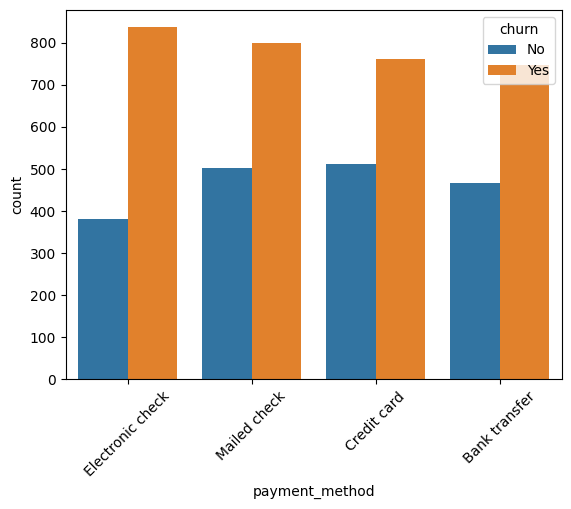

In [17]:
sns.countplot(x='payment_method', hue='churn', data=data)
plt.xticks(rotation=45)
plt.show()

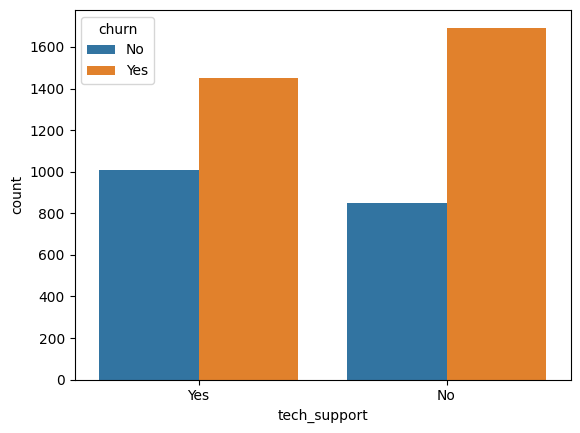

In [18]:
sns.countplot(x='tech_support', hue='churn', data=data)
plt.show()

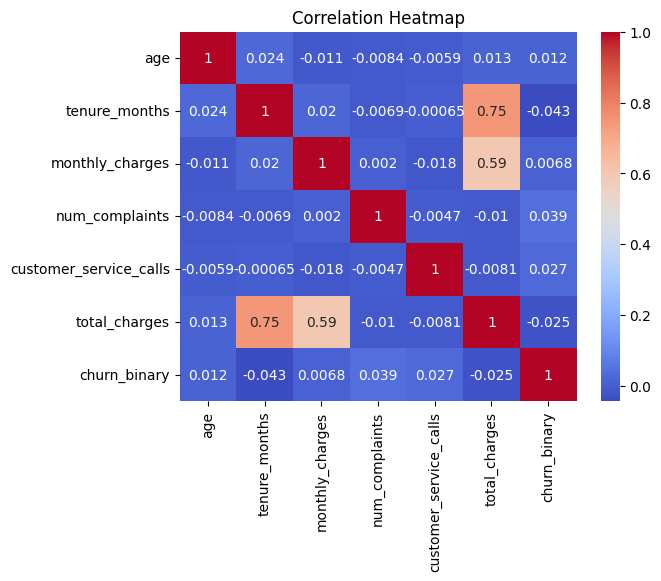

In [19]:
data['churn_binary'] = data['churn'].map({'No':0,'Yes':1})

numeric_data = data.select_dtypes(include='number')

sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()